In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('./data/College_Data')
# extracting dataset
# so the data set consists of:
# Private: A factor with levels No and Yes indicating private or public university
# Apps: Number of applications received
# Accept: Number of applications accepted
# Enroll: Number of new students enrolled
# Top10perc: Pct. new students from top 10% of H.S. class
# Top25perc: Pct. new students from top 25% of H.S. class
# F.Undergrad: Number of fulltime undergraduates
# P.Undergrad: Number of parttime undergraduates
# Outstate: Out-of-state tuition
# Room.Board: Room and board costs
# Books: Estimated book costs
# Personal: Estimated personal spending
# PhD: Pct. of faculty with Ph.D.’s
# Terminal: Pct. of faculty with terminal degree
# S.F.Ratio: Student/faculty ratio
# perc.alumni Pct. alumni who donate
# Expend Instructional expenditure per student
# Grad.Rate Graduation rate

In [3]:
df.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [4]:
df.dropna(inplace=True) #dropping columns containing NaN

In [5]:
df.describe() #checking no missing values

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [6]:
scaler = StandardScaler() # standardizing the data using the StandardScaler function from sklearn to account for variations in measurements units and scale. It will be done by taking the feature, subtracting the mean of the feature from the values, then dividing by the feature's standard deviation. the process, of course, can be influenced by outliers within the data, so those have to be identified and dealt with prior to standardization.

In [7]:
df[['app_t', 'acc_t', 'enr_t']] = scaler.fit_transform(df[['Apps', 'Accept', 'Enroll']])
df #add those 2 new columns working with scaler

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,app_t,acc_t,enr_t
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,2200,70,78,18.1,12,7041,60,-0.346882,-0.321205,-0.063509
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,1500,29,30,12.2,16,10527,56,-0.210884,-0.038703,-0.288584
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,1165,53,66,12.9,30,8735,54,-0.406866,-0.376318,-0.478121
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,875,92,97,7.7,37,19016,59,-0.668261,-0.681682,-0.692427
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,1500,76,72,11.9,2,10922,15,-0.726176,-0.764555,-0.780735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,1200,60,60,21.0,14,4469,40,-0.208040,-0.205673,-0.255200
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,1250,73,75,13.3,31,9189,83,-0.269575,-0.087284,-0.091509
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,781,67,75,14.4,20,8323,49,-0.233895,-0.042377,-0.091509
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,2115,96,96,5.8,49,40386,99,1.991711,0.177256,0.578333


In [8]:
# working out optimum number of clusters

def optimise_k_means(data, max_k):
    means = []
    inertias = []

    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(data)

        means.append(k)
        inertias.append(kmeans.inertia_)

    # elbow plot
    fig = plt.subplots(figsize=(10,5))
    plt.plot(means, inertias, 'o-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

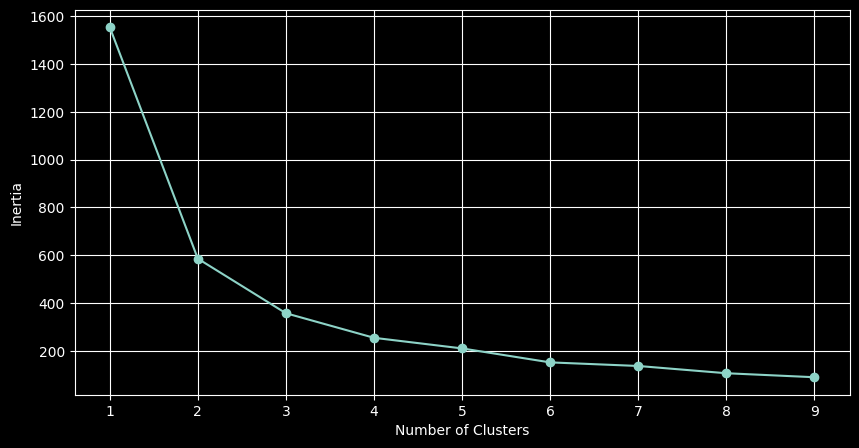

In [9]:
optimise_k_means(df[['app_t', 'enr_t']], 10) # so in this plot we can see that the inertia (sum of squared distances to the nearest cluster center) decreases as we increase the number of clusters. There is a big change in inertia and slope from 2 clusters onwards.

In [10]:
kmeans = KMeans(n_clusters=2) #applying k means clustering
kmeans.fit(df[['app_t', 'enr_t']]) #k means algorithm fit into data
df['kmeans_2'] = kmeans.labels_
df

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,app_t,acc_t,enr_t,kmeans_2
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,70,78,18.1,12,7041,60,-0.346882,-0.321205,-0.063509,0
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,29,30,12.2,16,10527,56,-0.210884,-0.038703,-0.288584,0
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,53,66,12.9,30,8735,54,-0.406866,-0.376318,-0.478121,0
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,92,97,7.7,37,19016,59,-0.668261,-0.681682,-0.692427,0
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,76,72,11.9,2,10922,15,-0.726176,-0.764555,-0.780735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,60,60,21.0,14,4469,40,-0.208040,-0.205673,-0.255200,0
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,73,75,13.3,31,9189,83,-0.269575,-0.087284,-0.091509,0
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,67,75,14.4,20,8323,49,-0.233895,-0.042377,-0.091509,0
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,96,96,5.8,49,40386,99,1.991711,0.177256,0.578333,1


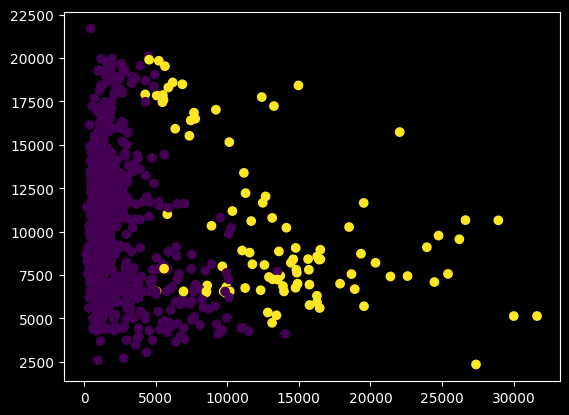

In [11]:
plt.scatter(x=df['F.Undergrad'], y=df['Outstate'], c=df['kmeans_2'])
# plt.xlim(-0.1, 1)
# plt.ylim(3,1.5)
plt.show() 

In [12]:
for k in range(1,6): # creating multiple clusters
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[['app_t', 'enr_t']])
    df[f'KMeans_{k}'] = kmeans.labels_


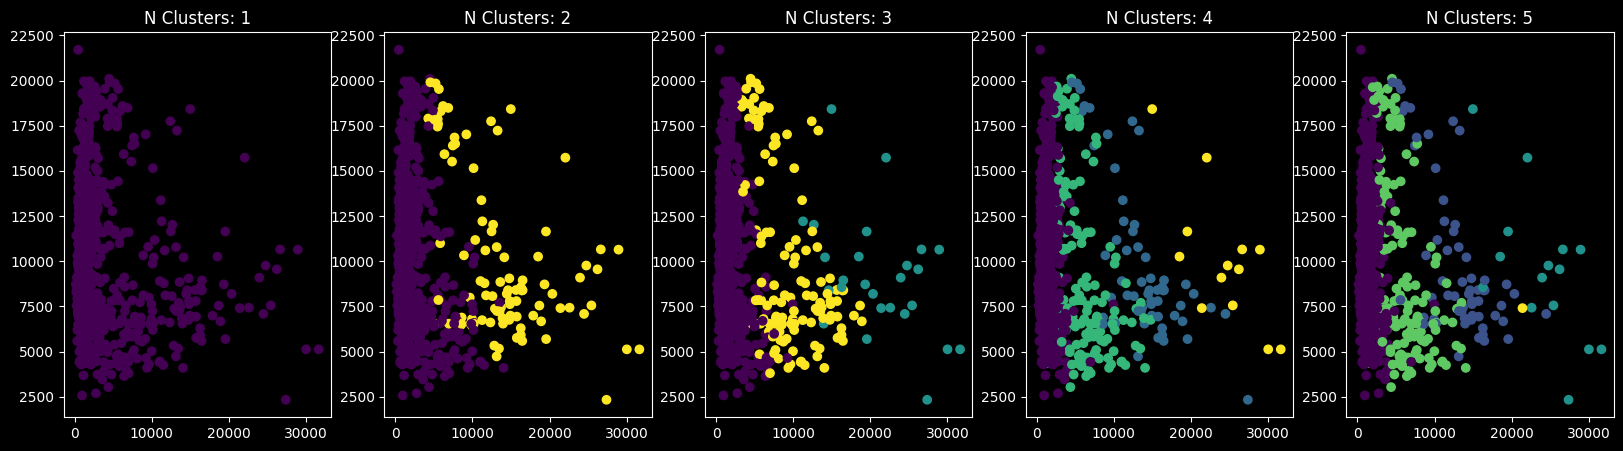

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))

for i, ax in enumerate(fig.axes, start=1):
    ax.scatter(x=df['F.Undergrad'], y=df['Outstate'], c=df[f'KMeans_{i}'])
    # ax.set_ylim(3,1.5)
    # ax.set_xlim(0,1)
    ax.set_title(f'N Clusters: {i}')